In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

WORK_DIR    = '/content/drive/MyDrive/visdrone/task2_traffic'
OUTPUT_DIR  = '/content/drive/MyDrive/visdrone/task2_outputs'

for d in [WORK_DIR, OUTPUT_DIR]:
    os.makedirs(d, exist_ok=True)


DRIVE_ROOT  = '/content/drive/MyDrive/visdrone'
TRAIN_DIR   = f'{DRIVE_ROOT}/VisDrone2019-DET-train/VisDrone2019-DET-train'
VAL_DIR     = f'{DRIVE_ROOT}/VisDrone2019-DET-val/VisDrone2019-DET-val'
TEST_DIR    = f'{DRIVE_ROOT}/VisDrone2019-DET-test-dev/VisDrone2019-DET-test-dev'

In [ ]:
import torch, os
print(f'CUDA: {torch.cuda.is_available()} | GPU: {torch.cuda.get_device_name(0)}')

DRIVE_ROOT  = '/content/drive/MyDrive/visdrone'
TRAIN_DIR   = f'{DRIVE_ROOT}/VisDrone2019-DET-train/VisDrone2019-DET-train'
VAL_DIR     = f'{DRIVE_ROOT}/VisDrone2019-DET-val/VisDrone2019-DET-val'
TEST_DIR    = f'{DRIVE_ROOT}/VisDrone2019-DET-test-dev/VisDrone2019-DET-test-dev'
WORK_DIR    = '/content/task2_traffic'
OUTPUT_DIR  = '/content/task2_outputs'

for d in [WORK_DIR, OUTPUT_DIR]:
    os.makedirs(d, exist_ok=True)

for name, path in [('train', TRAIN_DIR), ('val', VAL_DIR), ('test', TEST_DIR)]:
    n_imgs = len(os.listdir(f'{path}/images')) if os.path.exists(f'{path}/images') else 0
    n_ann  = len(os.listdir(f'{path}/annotations')) if os.path.exists(f'{path}/annotations') else 0
    print(f'  {name}: {n_imgs} images, {n_ann} annotations')

CUDA: True | GPU: Tesla T4
  train: 6471 images, 6471 annotations
  val: 548 images, 548 annotations
  test: 1610 images, 1610 annotations


In [ ]:
!pip install -qq ultralytics
!pip install -qq lap
!pip install -qq filterpy
!pip install -qq motmetrics
!pip install -qq geopandas shapely rasterio

import ultralytics
print(f'Ultralytics version: {ultralytics.__version__}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 46.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 13.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.5/161.5 kB 9.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics version: 8.4.28


In [ ]:
%%writefile /content/drive/MyDrive/visdrone/task2_traffic/visdrone_to_yolo.py
"""
Converts VisDrone DET annotations to YOLO format.

VisDrone annotation format (per line):
  <bbox_left>,<bbox_top>,<bbox_width>,<bbox_height>,<score>,<category>,<truncation>,<occlusion>

VisDrone categories:
  0=ignored, 1=pedestrian, 2=people, 3=bicycle, 4=car, 5=van,
  6=truck, 7=tricycle, 8=awning-tricycle, 9=bus, 10=motor, 11=others

We map to 5 vehicle classes relevant to traffic analysis:
  0=car, 1=truck, 2=bus, 3=motorcycle, 4=bicycle
"""

import os
import shutil
from pathlib import Path
from PIL import Image

# ignored(0), pedestrian(1), people(2), bicycle(3), car(4),
# van(5), truck(6), tricycle(7), awning-tricycle(8), bus(9), motor(10), others(11)
VISDRONE_TO_YOLO = {
    4:  0,   # car remains car
    5:  1,   # van  changes to truck
    6:  1,   # truck remains truck
    9:  2,   # bus remains bus
    10: 3,   # motor reamins motor
    3:  4,   # bicycle remains bicycle
    7:  3,   # tricycle changes to motorcycle
    8:  3,   # awning-tricycle changes to motorcycle
}
CLASS_NAMES = ['car', 'truck', 'bus', 'motorcycle', 'bicycle']
NUM_CLASSES = len(CLASS_NAMES)


def convert_split(src_dir: str, dst_dir: str, split: str):
    img_src = Path(src_dir) / 'images'
    ann_src = Path(src_dir) / 'annotations'
    img_dst = Path(dst_dir) / 'images' / split
    lbl_dst = Path(dst_dir) / 'labels' / split
    img_dst.mkdir(parents=True, exist_ok=True)
    lbl_dst.mkdir(parents=True, exist_ok=True)

    skipped = converted = 0
    ann_files = sorted(ann_src.glob('*.txt'))

    for ann_path in ann_files:
        stem = ann_path.stem

        # Find matching image
        img_path = None
        for ext in ['.jpg', '.jpeg', '.png']:
            candidate = img_src / (stem + ext)
            if candidate.exists():
                img_path = candidate
                break
        if img_path is None:
            skipped += 1
            continue

        with Image.open(img_path) as im:
            W, H = im.size
        yolo_lines = []
        with open(ann_path) as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                parts = line.split(',')
                if len(parts) < 6:
                    continue
                x1, y1, bw, bh = int(parts[0]), int(parts[1]), int(parts[2]), int(parts[3])
                score    = int(parts[4])  
                visdrone_cls = int(parts[5])

                if score == 0:           
                    continue
                if visdrone_cls not in VISDRONE_TO_YOLO:
                    continue            
                if bw <= 0 or bh <= 0:
                    continue

                yolo_cls = VISDRONE_TO_YOLO[visdrone_cls]

                cx = (x1 + bw / 2) / W
                cy = (y1 + bh / 2) / H
                nw = bw / W
                nh = bh / H


                cx = max(0.0, min(1.0, cx))
                cy = max(0.0, min(1.0, cy))
                nw = max(0.0, min(1.0, nw))
                nh = max(0.0, min(1.0, nh))

                yolo_lines.append(f'{yolo_cls} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}')


        shutil.copy(img_path, img_dst / img_path.name)


        with open(lbl_dst / (stem + '.txt'), 'w') as f:
            f.write('\n'.join(yolo_lines))

        converted += 1

    print(f'  {split}: {converted} converted, {skipped} skipped')
    return converted


def write_yaml(dst_dir: str, yaml_path: str):
    content = f"""path: {dst_dir}
train: images/train
val: images/val
test: images/test

nc: {NUM_CLASSES}
names: {CLASS_NAMES}
"""
    with open(yaml_path, 'w') as f:
        f.write(content)
    print(f'Dataset YAML {yaml_path}')

Writing /content/drive/MyDrive/visdrone/task2_traffic/visdrone_to_yolo.py


In [ ]:
import sys
sys.path.insert(0, '/content/drive/MyDrive/visdrone/task2_traffic')
from visdrone_to_yolo import convert_split, write_yaml

YOLO_DATA_DIR = '/content/drive/MyDrive/visdrone/task2_traffic/visdrone_yolo'
YAML_PATH     = '/content/drive/MyDrive/visdrone/task2_traffic/visdrone.yaml'

print('Converting VisDrone → YOLO format...')
convert_split(TRAIN_DIR, YOLO_DATA_DIR, 'train')
convert_split(VAL_DIR,   YOLO_DATA_DIR, 'val')
convert_split(TEST_DIR,  YOLO_DATA_DIR, 'test')
write_yaml(YOLO_DATA_DIR, YAML_PATH)
import os
for split in ['train', 'val', 'test']:
    n_imgs = len(os.listdir(f'{YOLO_DATA_DIR}/images/{split}'))
    n_lbls = len(os.listdir(f'{YOLO_DATA_DIR}/labels/{split}'))
    print(f'  {split}: {n_imgs} images | {n_lbls} labels')

Converting VisDrone → YOLO format...
  train: 6471 converted, 0 skipped
  val: 548 converted, 0 skipped
  test: 1610 converted, 0 skipped
Dataset YAML → /content/drive/MyDrive/visdrone/task2_traffic/visdrone.yaml
  train: 6471 images | 6471 labels
  val: 548 images | 548 labels
  test: 1610 images | 1610 labels


In [ ]:
%%writefile /content/drive/MyDrive/visdrone/task2_traffic/yolo_trainer.py

from ultralytics import YOLO

def train_yolo(
    yaml_path,
    output_dir,
    epochs=30,
    imgsz=640,
    batch=16,
    model_variant='yolov8m.pt',
    resume=False,
    fraction=1.0,   
    cache=False,  
):
    model = YOLO(model_variant)
    results = model.train(
        data          = yaml_path,
        epochs        = epochs,
        imgsz         = imgsz,
        batch         = batch,
        device        = 0,
        project       = output_dir,
        name          = 'visdrone_yolov8m',
        exist_ok      = True,
        resume        = resume,
        fraction      = fraction,
        cache         = cache,    

        # Small object strategies
        mosaic        = 1.0,
        mixup         = 0.1,
        copy_paste    = 0.1,
        scale         = 0.5,
        fliplr        = 0.5,
        flipud        = 0.3,
        degrees       = 10.0,

        # Training config
        optimizer     = 'AdamW',
        lr0           = 0.001,
        lrf           = 0.01,
        warmup_epochs = 3,
        cos_lr        = True,
        weight_decay  = 0.0005,
        label_smoothing = 0.1,

        save          = True,
        save_period   = 5,
        plots         = True,
        val           = True,
        verbose       = True,
    )
    return results


def evaluate_yolo(model_path, yaml_path, imgsz=640):
    model   = YOLO(model_path)
    metrics = model.val(data=yaml_path, imgsz=imgsz, device=0, split='val', verbose=True)
    print(f'\nmAP@0.5  : {metrics.box.map50:.4f}')
    print(f'mAP@0.5:95: {metrics.box.map:.4f}')
    names = ['car', 'truck', 'bus', 'motorcycle', 'bicycle']
    for name, ap in zip(names, metrics.box.ap50):
        print(f'  {name:<12} {ap:.4f}')
    return metrics

Overwriting /content/drive/MyDrive/visdrone/task2_traffic/yolo_trainer.py


In [ ]:
%%writefile /content/drive/MyDrive/visdrone/task2_traffic/bytetrack.py
"""
Task 2 - ByteTrack multi-object tracker wrapper.
YOLOv8 has ByteTrack built-in via model.track().
This module handles the tracking loop + trajectory storage
for MOTA/IDF1 evaluation and heatmap generation.
"""

import os
import json
import numpy as np
import cv2
from pathlib import Path
from typing import List, Dict, Optional
from ultralytics import YOLO


CLASS_NAMES = ['car', 'truck', 'bus', 'motorcycle', 'bicycle']
COLORS = [
    (0, 114, 255),    # car       - blue
    (0, 200, 100),    # truck     - green
    (255, 100, 0),    # bus       - orange
    (180, 0, 255),    # motorcycle- purple
    (255, 220, 0),    # bicycle   - yellow
]


class TrajectoryStore:
    """Stores per-track trajectory for heatmap and evaluation."""

    def __init__(self):
        self.tracks: Dict[int, List[Dict]] = {} 

    def update(self, frame_id: int, track_id: int, bbox_xyxy: List,
               cls: int, conf: float):
        if track_id not in self.tracks:
            self.tracks[track_id] = []
        cx = (bbox_xyxy[0] + bbox_xyxy[2]) / 2
        cy = (bbox_xyxy[1] + bbox_xyxy[3]) / 2
        self.tracks[track_id].append({
            'frame': frame_id,
            'bbox':  bbox_xyxy,
            'cx': cx, 'cy': cy,
            'cls': cls,
            'conf': conf,
        })

    def all_centers(self) -> np.ndarray:
        """Return all (cx, cy) points across all tracks — for heatmap."""
        pts = []
        for detections in self.tracks.values():
            for d in detections:
                pts.append([d['cx'], d['cy']])
        return np.array(pts, dtype=np.float32) if pts else np.zeros((0, 2))

    def save(self, path: str):
        with open(path, 'w') as f:
            json.dump(self.tracks, f, indent=2)

    def summary(self) -> Dict:
        total_detections = sum(len(v) for v in self.tracks.values())
        cls_counts = {n: 0 for n in CLASS_NAMES}
        for detections in self.tracks.values():
            for d in detections:
                if d['cls'] < len(CLASS_NAMES):
                    cls_counts[CLASS_NAMES[d['cls']]] += 1
        return {
            'total_tracks': len(self.tracks),
            'total_detections': total_detections,
            'class_counts': cls_counts,
        }


def track_image_sequence(
    model_path: str,
    image_dir: str,
    output_dir: str,
    conf_thresh: float = 0.25,
    iou_thresh:  float = 0.45,
    imgsz: int = 1280,
    save_annotated: bool = True,
) -> TrajectoryStore:
    model = YOLO(model_path)
    store = TrajectoryStore()
    out_dir = Path(output_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    images = sorted(Path(image_dir).glob('*.jpg')) + \
             sorted(Path(image_dir).glob('*.png'))

    print(f'Tracking {len(images)} frames with ByteTrack...')

    for frame_id, img_path in enumerate(images):
        results = model.track(
            source    = str(img_path),
            tracker   = 'bytetrack.yaml',
            conf      = conf_thresh,
            iou       = iou_thresh,
            imgsz     = imgsz,
            persist   = True,  
            verbose   = False,
        )

        result = results[0]
        if result.boxes is None or result.boxes.id is None:
            continue

        boxes    = result.boxes.xyxy.cpu().numpy()
        track_ids= result.boxes.id.cpu().numpy().astype(int)
        classes  = result.boxes.cls.cpu().numpy().astype(int)
        confs    = result.boxes.conf.cpu().numpy()

        for box, tid, cls, conf in zip(boxes, track_ids, classes, confs):
            store.update(frame_id, int(tid), box.tolist(), cls, float(conf))


        if save_annotated and frame_id < 50:  
            annotated = draw_tracks(result, store, frame_id)
            cv2.imwrite(str(out_dir / f'frame_{frame_id:04d}.jpg'), annotated)

        if frame_id % 20 == 0:
            print(f'  Frame {frame_id}/{len(images)} | '
                  f'Active tracks: {len(store.tracks)}')

    store.save(str(out_dir / 'trajectories.json'))
    summary = store.summary()
    print(f'\nTracking complete:')
    print(f'  Total unique tracks : {summary["total_tracks"]}')
    print(f'  Total detections    : {summary["total_detections"]}')
    print(f'  Class breakdown     : {summary["class_counts"]}')
    return store


def draw_tracks(result, store: TrajectoryStore, frame_id: int) -> np.ndarray:
    """Draw bounding boxes, track IDs, and recent trajectory tails."""
    frame = result.orig_img.copy()

    if result.boxes is None or result.boxes.id is None:
        return frame

    boxes     = result.boxes.xyxy.cpu().numpy()
    track_ids = result.boxes.id.cpu().numpy().astype(int)
    classes   = result.boxes.cls.cpu().numpy().astype(int)
    confs     = result.boxes.conf.cpu().numpy()

    for box, tid, cls, conf in zip(boxes, track_ids, classes, confs):
        x1, y1, x2, y2 = map(int, box)
        color = COLORS[cls % len(COLORS)]
        label = f'{CLASS_NAMES[cls]} #{tid} {conf:.2f}'


        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)


        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(frame, (x1, y1 - th - 4), (x1 + tw, y1), color, -1)
        cv2.putText(frame, label, (x1, y1 - 2),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

        if tid in store.tracks:
            recent = store.tracks[tid][-15:]
            pts = [(int(d['cx']), int(d['cy'])) for d in recent]
            for i in range(1, len(pts)):
                alpha = i / len(pts)
                c = tuple(int(v * alpha) for v in color)
                cv2.line(frame, pts[i-1], pts[i], c, 2)

    return frame

Overwriting /content/drive/MyDrive/visdrone/task2_traffic/bytetrack.py


In [ ]:
%%writefile /content/drive/MyDrive/visdrone/task2_traffic/heatmap.py
import json
import numpy as np
import cv2
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
from scipy.ndimage import gaussian_filter
from typing import Optional


def build_density_map(
    points: np.ndarray,
    image_shape: tuple,
    sigma: float = 15.0,
) -> np.ndarray:
    H, W = image_shape[:2]
    density = np.zeros((H, W), dtype=np.float32)

    for cx, cy in points:
        x, y = int(np.clip(cx, 0, W-1)), int(np.clip(cy, 0, H-1))
        density[y, x] += 1.0


    density = gaussian_filter(density, sigma=sigma)


    if density.max() > 0:
        density = density / density.max()

    return density


def build_grid_density(
    points: np.ndarray,
    image_shape: tuple,
    grid_size: int = 50,
) -> np.ndarray:
    H, W = image_shape[:2]
    rows = H // grid_size
    cols = W // grid_size
    grid = np.zeros((rows, cols), dtype=np.int32)

    for cx, cy in points:
        r = int(np.clip(cy // grid_size, 0, rows - 1))
        c = int(np.clip(cx // grid_size, 0, cols - 1))
        grid[r, c] += 1

    return grid


def overlay_heatmap(
    frame: np.ndarray,
    density: np.ndarray,
    alpha: float = 0.55,
    colormap: int = cv2.COLORMAP_JET,
) -> np.ndarray:
    density_u8 = (density * 255).astype(np.uint8)
    heatmap_bgr = cv2.applyColorMap(density_u8, colormap)
    heatmap_bgr = cv2.resize(heatmap_bgr, (frame.shape[1], frame.shape[0]))
    mask = (density_u8 > 10).astype(np.float32)
    mask = cv2.resize(mask, (frame.shape[1], frame.shape[0]))
    mask = mask[..., np.newaxis]

    blended = frame.astype(np.float32) * (1 - alpha * mask) + \
              heatmap_bgr.astype(np.float32) * alpha * mask
    return blended.astype(np.uint8)


def generate_heatmap(
    trajectories_path: str,
    reference_frame_path: str,
    output_dir: str,
    sigma: float = 20.0,
    grid_size: int = 50,
):
    out_dir = Path(output_dir)
    out_dir.mkdir(parents=True, exist_ok=True)


    with open(trajectories_path) as f:
        tracks = json.load(f)

    all_points = []
    for detections in tracks.values():
        for d in detections:
            all_points.append([d['cx'], d['cy']])
    points = np.array(all_points, dtype=np.float32)
    print(f'Total vehicle positions: {len(points)}')

    ref = cv2.imread(reference_frame_path)
    if ref is None:
        raise FileNotFoundError(f'Reference frame not found: {reference_frame_path}')
    H, W = ref.shape[:2]


    density = build_density_map(points, (H, W), sigma=sigma)


    overlay = overlay_heatmap(ref, density)
    cv2.imwrite(str(out_dir / 'heatmap_overlay.png'), overlay)
    print(f'Saved: heatmap_overlay.png')


    fig, ax = plt.subplots(figsize=(12, 8))
    im = ax.imshow(density, cmap='hot', aspect='auto', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, label='Vehicle density (normalised)')
    ax.set_title('Traffic Density Heatmap — VisDrone Aerial View', fontsize=14)
    ax.axis('off')
    fig.savefig(str(out_dir / 'heatmap_standalone.png'), dpi=150, bbox_inches='tight')
    plt.close()
    print(f'Saved: heatmap_standalone.png')


    grid = build_grid_density(points, (H, W), grid_size=grid_size)
    fig, ax = plt.subplots(figsize=(12, 8))
    im = ax.imshow(grid, cmap='YlOrRd', aspect='auto')
    plt.colorbar(im, ax=ax, label='Vehicle count per cell')
    ax.set_title(f'Vehicle Count Grid ({grid_size}px cells)', fontsize=14)
    fig.savefig(str(out_dir / 'density_grid.png'), dpi=150, bbox_inches='tight')
    plt.close()
    print(f'Saved: density_grid.png')


    summary = {
        'total_vehicle_positions': len(points),
        'peak_density_region': {
            'y': int(np.unravel_index(density.argmax(), density.shape)[0]),
            'x': int(np.unravel_index(density.argmax(), density.shape)[1]),
        },
        'grid_max_count': int(grid.max()),
        'grid_mean_count': round(float(grid.mean()), 2),
    }
    import json as _json
    with open(out_dir / 'heatmap_summary.json', 'w') as f:
        _json.dump(summary, f, indent=2)
    print(f'Summary: {summary}')
    return density, grid

Overwriting /content/drive/MyDrive/visdrone/task2_traffic/heatmap.py


In [ ]:
%%writefile /content/drive/MyDrive/visdrone/task2_traffic/evaluate_mot.py
import os
import json
import numpy as np
import motmetrics as mm
from pathlib import Path
from ultralytics import YOLO


def load_visdrone_gt(ann_path: str) -> list:
    detections = []
    with open(ann_path) as f:
        for line in f:
            parts = line.strip().split(',')
            if len(parts) < 6:
                continue
            x, y, w, h = int(parts[0]), int(parts[1]), int(parts[2]), int(parts[3])
            score = int(parts[4])
            cls   = int(parts[5])
            if score == 0 or w <= 0 or h <= 0:
                continue
            detections.append([0, cls, x, y, w, h])
    return detections


def evaluate_detection(
    model_path: str,
    image_dir: str,
    ann_dir: str,
    imgsz: int = 1280,
    conf: float = 0.25,
    max_images: int = 50,
) -> dict:
    model  = YOLO(model_path)
    acc    = mm.MOTAccumulator(auto_id=True)

    images = sorted(Path(image_dir).glob('*.jpg'))[:max_images]
    print(f'Evaluating on {len(images)} images...')

    VEHICLE_CLASSES = {3, 4, 5, 6, 7, 8, 9, 10}

    for img_path in images:
        ann_path = Path(ann_dir) / (img_path.stem + '.txt')
        if not ann_path.exists():
            continue

        gt_raw = load_visdrone_gt(str(ann_path))
        gt_ids  = list(range(len(gt_raw)))
        gt_boxes = np.array([[g[2], g[3], g[2]+g[4], g[3]+g[5]]
                              for g in gt_raw], dtype=np.float32)
        results = model.track(
            source  = str(img_path),
            conf    = conf,
            imgsz   = imgsz,
            persist = False,
            verbose = False,
            tracker = 'bytetrack.yaml',
        )
        result = results[0]

        if result.boxes is None or len(result.boxes) == 0:
            pred_ids, pred_boxes = [], np.zeros((0, 4))
        else:
            pred_ids   = (result.boxes.id.cpu().numpy().astype(int).tolist()
                          if result.boxes.id is not None else
                          list(range(len(result.boxes))))
            pred_boxes = result.boxes.xyxy.cpu().numpy()
        if len(gt_boxes) > 0 and len(pred_boxes) > 0:
            dist = mm.distances.iou_matrix(
                gt_boxes, pred_boxes, max_iou=0.5
            )
        else:
            dist = np.empty((len(gt_ids), len(pred_ids)))
            dist[:] = np.nan

        acc.update(gt_ids, pred_ids, dist)
    mh = mm.metrics.create()
    summary = mh.compute(
        acc,
        metrics=['num_frames', 'mota', 'motp', 'idf1',
                 'num_switches', 'num_misses', 'num_false_positives'],
        name='VisDrone'
    )
    print('\n', '─'*2, 'Tracking Metrics', '─'*40)
    print(mm.io.render_summary(summary, namemap=mm.io.motchallenge_metric_names))

    return {
        'MOTA':  float(summary['mota'].iloc[0]),
        'MOTP':  float(summary['motp'].iloc[0]),
        'IDF1':  float(summary['idf1'].iloc[0]),
        'num_switches': int(summary['num_switches'].iloc[0]),
    }

Overwriting /content/drive/MyDrive/visdrone/task2_traffic/evaluate_mot.py


In [ ]:
import sys
sys.path.insert(0, '/content/drive/MyDrive/visdrone/task2_traffic')
from yolo_trainer import train_yolo

results = train_yolo(
    yaml_path   = '/content/drive/MyDrive/visdrone/task2_traffic/visdrone.yaml',
    output_dir  = '/content/drive/MyDrive/visdrone/task2_outputs',
    epochs      = 80,
    imgsz       = 640,
    batch       = 2,
    model_variant = 'yolov8m.pt',
    resume      = False,      
    fraction      = 0.3,        
    cache         = True,    
)

BEST_MODEL = '/content/drive/MyDrive/visdrone/task2_outputs/visdrone_yolov8m/weights/best.pt'
print(f'\nBest model: {BEST_MODEL}')

New https://pypi.org/project/ultralytics/8.4.30 available 😃 Update with 'pip install -U ultralytics'
WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.28 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/visdrone/task2_traffic/visdrone.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.3, format=torchscript, fraction=0.3, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, m

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
BEST_MODEL = '/content/drive/MyDrive/visdrone/task2_outputs/visdrone_yolov8m/weights/last.pt'
size = os.path.getsize(BEST_MODEL) / 1e6
print(f'Checkpoint found: {size:.1f} MB')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checkpoint found: 155.7 MB


In [ ]:
import os

base = '/content/drive/MyDrive/visdrone/task2_outputs/visdrone_yolov8m/weights'
for f in ['best.pt', 'last.pt']:
    path = f'{base}/{f}'
    if os.path.exists(path):
        size = os.path.getsize(path) / 1e6
        print(f'{f}: {size:.1f} MB ✓')
    else:
        print(f'{f}: NOT FOUND ✗')

best.pt: 155.7 MB ✓
last.pt: 155.7 MB ✓


In [ ]:
!pip install -qq ultralytics motmetrics lap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.5/161.5 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 76.1 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

YAML = '/content/drive/MyDrive/visdrone/task2_traffic/visdrone.yaml'
model = YOLO("/content/drive/MyDrive/visdrone/task2_outputs/visdrone_yolov8m/weights/best.pt")
metrics = model.val(data=YAML, imgsz=640, device=0, split='val', verbose=True)

print(f'\n── Results ───────────────────────')
print(f'mAP@0.5    : {metrics.box.map50:.4f}')
print(f'mAP@0.5:95 : {metrics.box.map:.4f}')
names = ['car', 'truck', 'bus', 'motorcycle', 'bicycle']
for name, ap in zip(names, metrics.box.ap50):
    print(f'  {name:<14} {ap:.4f}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.30 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,842,655 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 0.3±0.0 MB/s, size: 121.3 KB)
val: Scanning /content/drive/MyDrive/visdrone/task2_traffic/visdrone_yolo/labels/val.cache... 548 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 65.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 1.7it/s 20.8s
                   all        548      24790      0.601      0.481      0.509      0.298
                   car        515      14064      0.73

In [ ]:
VAL_DIR = '/content/drive/MyDrive/visdrone/VisDrone2019-DET-val/VisDrone2019-DET-val'
OUT_DIR = '/content/drive/MyDrive/visdrone/task2_outputs'

model.track(
    source  = f'{VAL_DIR}/images',
    tracker = 'bytetrack.yaml',
    conf    = 0.25,
    imgsz   = 640,
    save    = True,
    project = OUT_DIR,
    name    = 'tracking_results',
)
print('Tracking done.')


image 1/548 /content/drive/MyDrive/visdrone/VisDrone2019-DET-val/VisDrone2019-DET-val/images/0000001_02999_d_0000005.jpg: 384x640 22 cars, 1 truck, 33 motorcycles, 47.2ms
image 2/548 /content/drive/MyDrive/visdrone/VisDrone2019-DET-val/VisDrone2019-DET-val/images/0000001_03499_d_0000006.jpg: 384x640 23 cars, 3 trucks, 19 motorcycles, 25.0ms
image 3/548 /content/drive/MyDrive/visdrone/VisDrone2019-DET-val/VisDrone2019-DET-val/images/0000001_03999_d_0000007.jpg: 384x640 4 cars, 22 motorcycles, 25.3ms
image 4/548 /content/drive/MyDrive/visdrone/VisDrone2019-DET-val/VisDrone2019-DET-val/images/0000001_04527_d_0000008.jpg: 384x640 4 cars, 1 truck, 32 motorcycles, 25.0ms
image 5/548 /content/drive/MyDrive/visdrone/VisDrone2019-DET-val/VisDrone2019-DET-val/images/0000001_05249_d_0000009.jpg: 384x640 93 cars, 14 trucks, 13 motorcycles, 25.1ms
image 6/548 /content/drive/MyDrive/visdrone/VisDrone2019-DET-val/VisDrone2019-DET-val/images/0000001_05499_d_0000010.jpg: 384x640 64 cars, 9 trucks, 18 

In [ ]:
import sys
sys.path.insert(0, '/content/drive/MyDrive/visdrone/task2_traffic')
from heatmap import generate_heatmap

import os
val_images = sorted(os.listdir(f'{VAL_DIR}/images'))
ref_frame  = f'{VAL_DIR}/images/{val_images[0]}'

generate_heatmap(
    trajectories_path    = f'{OUT_DIR}/tracking/trajectories.json',
    reference_frame_path = ref_frame,
    output_dir           = f'{OUT_DIR}/heatmaps',
)

from IPython.display import Image, display
display(Image(f'{OUT_DIR}/heatmaps/heatmap_overlay.png', width=800))

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/visdrone/task2_outputs/tracking_results/trajectories.json'

In [ ]:
import os, json
import numpy as np
from ultralytics import YOLO

VAL_DIR    = '/content/drive/MyDrive/visdrone/VisDrone2019-DET-val/VisDrone2019-DET-val'
OUT_DIR    = '/content/drive/MyDrive/visdrone/task2_outputs'
BEST_MODEL = f'{OUT_DIR}/visdrone_yolov8m/weights/best.pt'
TRACK_OUT  = f'{OUT_DIR}/tracking_results'
os.makedirs(TRACK_OUT, exist_ok=True)

model   = YOLO(BEST_MODEL)
images  = sorted([f for f in os.listdir(f'{VAL_DIR}/images')
                  if f.endswith(('.jpg', '.png'))])

tracks  = {} 

print(f'Tracking {len(images)} images...')
for frame_id, img_name in enumerate(images):
    img_path = f'{VAL_DIR}/images/{img_name}'
    results  = model.track(
        source  = img_path,
        tracker = 'bytetrack.yaml',
        conf    = 0.25,
        imgsz   = 640,
        persist = True,
        verbose = False,
    )
    result = results[0]
    if result.boxes is None or result.boxes.id is None:
        continue

    boxes     = result.boxes.xyxy.cpu().numpy()
    track_ids = result.boxes.id.cpu().numpy().astype(int)
    classes   = result.boxes.cls.cpu().numpy().astype(int)
    confs     = result.boxes.conf.cpu().numpy()

    for box, tid, cls, conf in zip(boxes, track_ids, classes, confs):
        tid = int(tid)
        cx  = float((box[0] + box[2]) / 2)
        cy  = float((box[1] + box[3]) / 2)
        if tid not in tracks:
            tracks[tid] = []
        tracks[tid].append({
            'frame': frame_id,
            'bbox':  box.tolist(),
            'cx': cx, 'cy': cy,
            'cls': int(cls),
            'conf': float(conf),
        })

    if frame_id % 50 == 0:
        print(f'  Frame {frame_id}/{len(images)} | Tracks so far: {len(tracks)}')

# Save trajectories
traj_path = f'{TRACK_OUT}/trajectories.json'
with open(traj_path, 'w') as f:
    json.dump(tracks, f)

print(f'\nDone. {len(tracks)} unique tracks saved → {traj_path}')

Tracking 548 images...
  Frame 0/548 | Tracks so far: 56
  Frame 150/548 | Tracks so far: 158
  Frame 200/548 | Tracks so far: 191
  Frame 250/548 | Tracks so far: 263
  Frame 300/548 | Tracks so far: 338
  Frame 350/548 | Tracks so far: 398
  Frame 400/548 | Tracks so far: 520
  Frame 450/548 | Tracks so far: 569
  Frame 500/548 | Tracks so far: 623

Done. 668 unique tracks saved → /content/drive/MyDrive/visdrone/task2_outputs/tracking_results/trajectories.json


In [25]:
from ultralytics import YOLO

OUT_DIR    = '/content/drive/MyDrive/visdrone/task2_outputs'
BEST_MODEL = f'{OUT_DIR}/visdrone_yolov8m/weights/best.pt'
YAML       = '/content/drive/MyDrive/visdrone/task2_traffic/visdrone.yaml'

model   = YOLO(BEST_MODEL)
metrics = model.val(data=YAML, imgsz=640, device=0, split='val', verbose=True)

print(f'\nmAP@0.5    : {metrics.box.map50:.4f}')
print(f'mAP@0.5:95 : {metrics.box.map:.4f}')
names = ['car', 'truck', 'bus', 'motorcycle', 'bicycle']
for name, ap in zip(names, metrics.box.ap50):
    print(f'  {name:<14} {ap:.4f}')

Ultralytics 8.4.30 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,842,655 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.1 ms, read: 0.3±0.2 MB/s, size: 132.3 KB)
val: Scanning /content/drive/MyDrive/visdrone/task2_traffic/visdrone_yolo/labels/val.cache... 548 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 82.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 1.5it/s 22.9s
                   all        548      24790      0.601      0.481      0.509      0.298
                   car        515      14064      0.732      0.789      0.809      0.518
                 truck        453       2725      0.606      0.452      0.489      0.303
                   bus        131        251      0.727      0.502      0.568      0.371
            motorcycle        503       6463      0.608      0.477      0.506      0.224
         

Using: 0000001_02999_d_0000005.jpg (56 detections)
Vehicle centers: 56


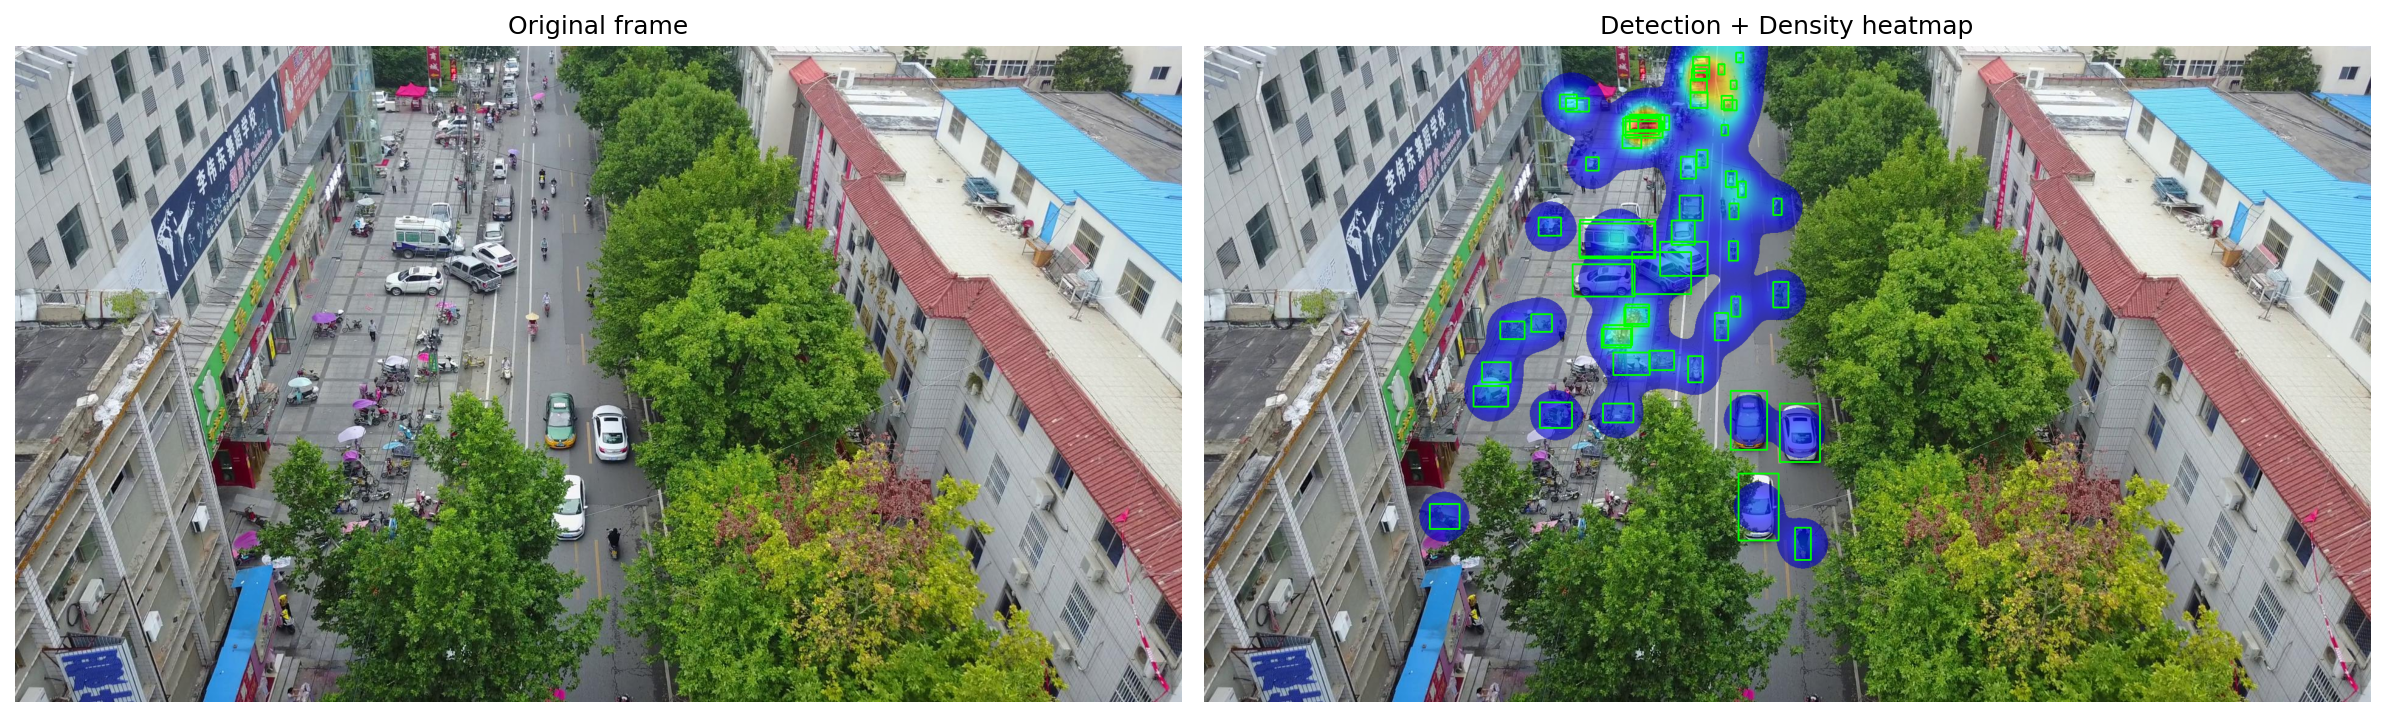

In [ ]:
import os, json
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from ultralytics import YOLO
from IPython.display import Image as IPImage, display

OUT_DIR    = '/content/drive/MyDrive/visdrone/task2_outputs'
VAL_DIR    = '/content/drive/MyDrive/visdrone/VisDrone2019-DET-val/VisDrone2019-DET-val'
BEST_MODEL = f'{OUT_DIR}/visdrone_yolov8m/weights/best.pt'

val_images = sorted(os.listdir(f'{VAL_DIR}/images'))

model = YOLO(BEST_MODEL)
os.makedirs(f'{OUT_DIR}/heatmaps', exist_ok=True)

for img_name in val_images:
    img_path = f'{VAL_DIR}/images/{img_name}'
    results  = model(img_path, imgsz=640, conf=0.25, verbose=False)
    boxes    = results[0].boxes
    if boxes is not None and len(boxes) >= 20:
        print(f'Using: {img_name} ({len(boxes)} detections)')
        break

ref  = cv2.imread(img_path)
H, W = ref.shape[:2]
points = []
for box in boxes.xyxy.cpu().numpy():
    cx = (box[0] + box[2]) / 2
    cy = (box[1] + box[3]) / 2
    points.append([cx, cy])
points = np.array(points)
print(f'Vehicle centers: {len(points)}')

density = np.zeros((H, W), dtype=np.float32)
for cx, cy in points:
    x, y = int(np.clip(cx, 0, W-1)), int(np.clip(cy, 0, H-1))
    density[y, x] += 1.0
density = gaussian_filter(density, sigma=25.0)
if density.max() > 0:
    density /= density.max()

density_u8  = (density * 255).astype(np.uint8)
heatmap_bgr = cv2.applyColorMap(density_u8, cv2.COLORMAP_JET)
mask        = (density > 0.05).astype(np.float32)[..., np.newaxis]
overlay     = (ref * (1 - 0.6 * mask) + heatmap_bgr * 0.6 * mask).astype(np.uint8)

for box in boxes.xyxy.cpu().numpy():
    x1,y1,x2,y2 = map(int, box)
    cv2.rectangle(overlay, (x1,y1), (x2,y2), (0,255,0), 2)

cv2.imwrite(f'{OUT_DIR}/heatmaps/heatmap_single_frame.png', overlay)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(cv2.cvtColor(ref, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original frame'); axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
axes[1].set_title('Detection + Density heatmap'); axes[1].axis('off')
plt.tight_layout()
fig.savefig(f'{OUT_DIR}/heatmaps/heatmap_final.png', dpi=150, bbox_inches='tight')
plt.close()

display(IPImage(f'{OUT_DIR}/heatmaps/heatmap_final.png', width=900))